<a href="https://colab.research.google.com/github/nibedita-26/airbnb_EDA/blob/main/notebooks/AirBnB_Booking_Analysis_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - AirBnb Booking Analysis



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Individual Member -** Nibedita Sahoo


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Analyze the AirBnb-NYC-2019 data to understand how pricing and availability vary across listings.




#### **Define Your Business Objective?**

Identify key factors influencing the pricing and demand to support better listing.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Dataset Loading

In [2]:
# Load Dataset
from google.colab import files
uploaded = files.upload()

Saving Airbnb NYC 2019.csv to Airbnb NYC 2019.csv


### Dataset First View

In [3]:
# Dataset First Look
df = pd.read_csv("/content/Airbnb NYC 2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
df.shape

(48895, 16)

### Dataset Information

In [6]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
df.isnull().sum().sort_values(ascending=False)

,0
last_review,10052
reviews_per_month,10052
host_name,21
name,16
neighbourhood_group,0
neighbourhood,0
id,0
host_id,0
longitude,0
latitude,0


In [9]:
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent.sort_values(ascending=False)

,0
last_review,20.558339
reviews_per_month,20.558339
host_name,0.042949
name,0.032723
neighbourhood_group,0.000000
neighbourhood,0.000000
id,0.000000
host_id,0.000000
longitude,0.000000
latitude,0.000000


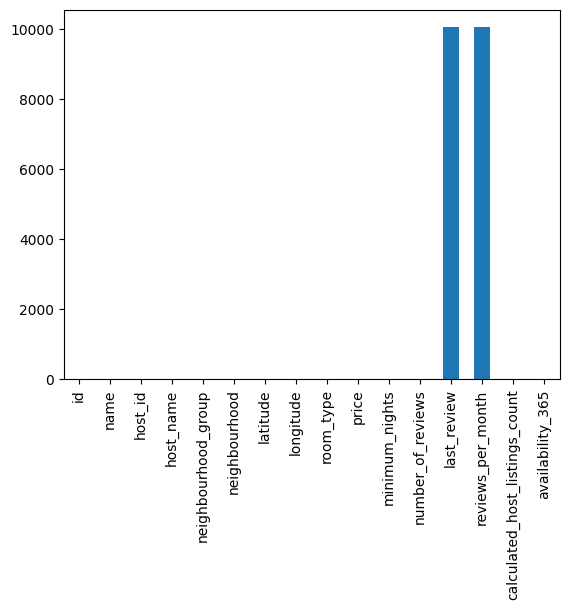

In [10]:
# Visualizing the missing values
df.isnull().sum().plot(kind='bar')
plt.show()

### What did you know about your dataset?

The dataset contains 48,895 AirBnb listings across New York city with 16 variables, indicating a moderately large dataset suitable for detailed analysis.

The variables include a mix of categorical (name, neighbourhood, room_type), numerical (price, availability, number_of_reviews) and date(last_review) variables. The last_review is in int

The dataset contains significant missing values in review related columns. Each of the columns 'last_review' and 'reviews_per_month' has 10052(20%) of missing entries. Additionaly, minor missing values are observed in 'host_name'(21, ~0.04%) and 'name'(16, ~0.03%).
The missing values in 'last_review' and 'reviews_per_month' are not random data quality issues but are logically consistent with listings that have no reviews. Therefore, these missing values represent inactive or new listings rather than errors in data.
A few missing values in name and host_name would not impact the analysis as the number is negligible compared to the dataset size.

There is no duplicated data in the dataset.

Key features include room_type, pricing, neighbourhood_group which ate likely to play major role in the listing performance and will be central to analysis.


## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [12]:
# Dataset Describe
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Variables Description

The dataset consists of multiple variables,representing listing details. These include identifiers, location information, pricing, avalilabilty, property features and  review related features.

Below are the different variables with a brief description:

Identifiers
id : Unique identifier for each listing
host_id : Unique identifier for each host

Location
neighbourhood_group : Broad location category (Manhattan, Brooklyn)
neighbourhood : Specific locality
latitude : Latitude
longitude : Longitude

Property features
room_type : Type of accomodation offered
minimum_nights : Minimum number of nights required for booking

Pricing & Availability
pricing : Price per night for the particular booking
availability_365 : Number of days the listing is available

Review related
number_of_reviews : Total number of reviews for the listed property
last_review : Date of the most recent review for the property
reviews_per_month : Average number of reviews per month

Text variables
name : listing name
host_name : Nmae of the host of the listing

These variables allow analysis of pricing behaviour, demand trends and geographic distribution of listings.

The summary statistics indicate the data contain many numeric variables. However, the statistics of latitude, longitude, id etc. are irrelavant in perspective of the data description. The pricing variable shows a great range of spread in the values indicating high variability and presence of outliers aswell.

The variables minimum_nights and availabilty_365 also exhibit a large spread indicating diverse listing policies.

Lastly, the variables related to reviews varies significantly, showing differences in popularity and customer engagement.



### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
df.nunique()

,0
id,48895
name,47905
host_id,37457
host_name,11452
neighbourhood_group,5
neighbourhood,221
latitude,19048
longitude,14718
room_type,3
price,674


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Write your code to make your dataset analysis ready.
# create copy of dataset
df_copy = df.copy()

In [15]:
#Check for duplictes
df_copy.duplicated().sum()

np.int64(0)

In [16]:
df_copy.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [17]:
# Handle missing values
df_copy['name'] = df_copy['name'].fillna('No Name')
df_copy['host_name'] = df_copy['host_name'].fillna('Unknown')
df_copy['reviews_per_month'] = df_copy['reviews_per_month'].fillna(0)


In [18]:
# convert last_review to datetime format
df_copy['last_review'] = pd.to_datetime(df_copy['last_review'])

In [19]:
df_copy.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [20]:
# remove unrealistic prices if any
df_copy[df_copy['price'] <= 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,NaT,0.00,1,0
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333


In [21]:
df_copy = df_copy[df_copy['price'] > 0]   # Listings cannot have zero or nagative prices

In [22]:
# check price distribution
df_copy['price'].describe()

,price
count,48884.000000
mean,152.755053
std,240.170260
min,10.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


In [23]:
# remove extreme outliers by iqr method
q1 = df_copy['price'].quantile(0.25)
q3 = df_copy['price'].quantile(0.75)

iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

df_copy = df_copy[
    (df_copy['price'] >= lower_bound) &
    (df_copy['price'] <= upper_bound)
]

In [24]:
# Create new features
# Occupancy proxy
df_copy['occupancy_rate'] = (
    365 - df_copy['availability_365']
) / 365

In [25]:
# Revenue_proxy
df_copy['revenue_proxy'] = (
    df_copy['price'] * df_copy['occupancy_rate']
)

In [26]:
# Extract year and month
df_copy['last_review_year'] = df_copy['last_review'].dt.year
df_copy['last_review_month'] = df_copy['last_review'].dt.month

In [27]:
# check final info
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45912 entries, 0 to 48894
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              45912 non-null  int64         
 1   name                            45912 non-null  object        
 2   host_id                         45912 non-null  int64         
 3   host_name                       45912 non-null  object        
 4   neighbourhood_group             45912 non-null  object        
 5   neighbourhood                   45912 non-null  object        
 6   latitude                        45912 non-null  float64       
 7   longitude                       45912 non-null  float64       
 8   room_type                       45912 non-null  object        
 9   price                           45912 non-null  int64         
 10  minimum_nights                  45912 non-null  int64         
 11  number_

In [28]:
df_copy.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,occupancy_rate,revenue_proxy,last_review_year,last_review_month
count,4.591200e+04,4.591200e+04,45912.000000,45912.000000,45912.000000,45912.000000,45912.000000,36901,45912.000000,45912.000000,45912.000000,45912.000000,45912.000000,36901.000000,36901.000000
mean,1.889813e+07,6.632877e+07,40.728492,-73.950739,119.999063,6.937968,23.940190,2018-10-02 17:09:19.106799360,1.107626,6.640268,109.375937,0.700340,82.418767,2018.284410,6.168180
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,10.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,2011.000000,1.000000
25%,9.435824e+06,7.720366e+06,40.689237,-73.981940,65.000000,1.000000,1.000000,2018-07-02 00:00:00,0.050000,1.000000,0.000000,0.405479,34.520548,2018.000000,5.000000
50%,1.952354e+07,3.028359e+07,40.721780,-73.954370,100.000000,2.000000,5.000000,2019-05-19 00:00:00,0.380000,1.000000,39.000000,0.893151,68.054795,2019.000000,6.000000
75%,2.891339e+07,1.055121e+08,40.763393,-73.934330,159.000000,5.000000,24.000000,2019-06-23 00:00:00,1.620000,2.000000,217.000000,1.000000,119.000000,2019.000000,7.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,334.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000,1.000000,331.090411,2019.000000,12.000000
std,1.092050e+07,7.756370e+07,0.055333,0.046473,68.133003,19.859505,45.316221,NaN,1.612588,31.011826,130.284368,0.356943,65.439833,1.181567,2.529524


### What all manipulations have you done and insights you found?

The dataset was cleaned and prepared for analysis by handling missing values, correcting data types, checking for duplicate record and filtering unrealistic price values. Review related missing values were treated as indicators of inactive listings rather than data errors.

Outlier handling was done on variable 'pricing' using the IQR method to reduce distortion in statistical analysis and visualizations. Additionally, new features occupancy_rate and revenue proxy were engineered to estimate listing performance and demand patterns.

These preprocessing steps ensured that the dataset became consistent, reliable, and suitable for exploratory data analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

-----------------
Univariate Analysis
-----------------
-----------------

#### Chart - 1 **Price Distribution**

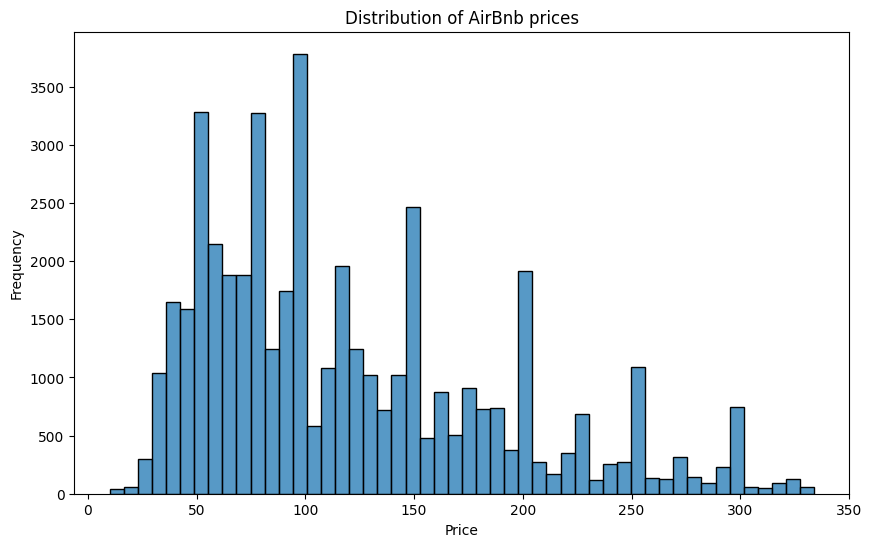

In [29]:
# Chart - 1 Price Distribution
plt.figure(figsize = (10, 6))

sns.histplot(df_copy['price'], bins = 50)

plt.title('Distribution of AirBnb prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


##### 1. Why did you pick the specific chart?

A histogram was used to understand the distribution of AirBnb listing prices and to identify skewness, spread, potential outliers.

##### 2. What is/are the insight(s) found from the chart?

The price distribution is heavily right-skewed, with most of the listings are concentrated at lower price range and a few are listed at extremely higher price range.

The presence of high-valued outliers significantly affect the price distribution and may dustort the statistical measures such as mean.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Extreme pricing variability among the listings suggests existence of multiple market segments, ranging from budget accomodation to luxury options. Pricing strategies should therefore be segment-specific rather than uniform.

Extreme pricing in small number of listings are less likely to get high demand when many affordable options are available.
Business Impact:
Lower occupancy rates
Reduced customer engagement
Poor conversion rates for hosts
Potential decline in platform competitiveness in premium segments

#### Chart - 2 **Log transformed price**

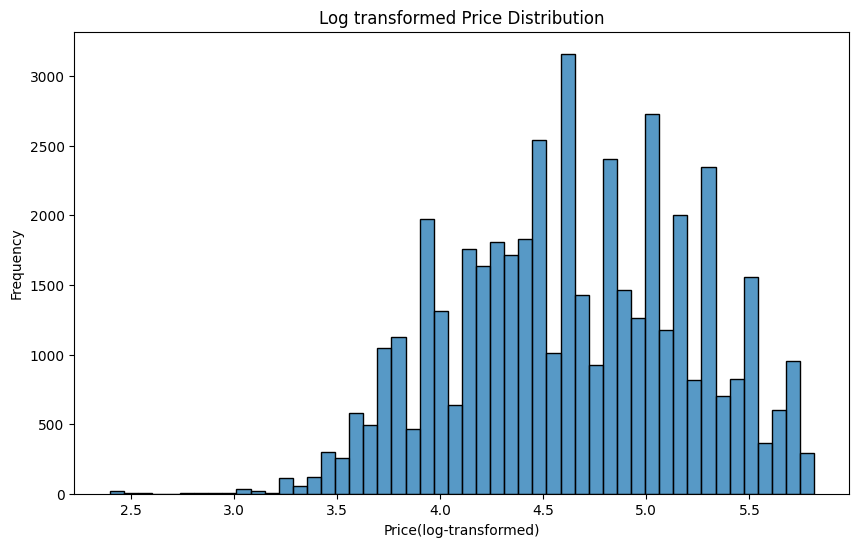

In [30]:
# Chart - 2 Log transformed price
df_copy['log_price'] = np.log1p(df_copy['price'])

plt.figure(figsize = (10, 6))

sns.histplot(df_copy['log_price'], bins = 50)

plt.title('Log transformed Price Distribution')
plt.xlabel('Price(log-transformed)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

Log transformation was applied to reduce the skewness better visualize the price distribution of listings.

##### 2. What is/are the insight(s) found from the chart?

The transformed price distribution appears approximately normal compared to the original price distribution.

Most of the listings are under moderate price segment, only a few are in the high-end price segment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the normalized pricing structure helps improve pricing analysis and supports more reliable statistical comparisons across listing categories.

Balanced pricing attracts a wider customer base and improves booking frequency.

Business Impact   
-> Better occupancy rates   

#### Chart - 3 **Room type Distribution**

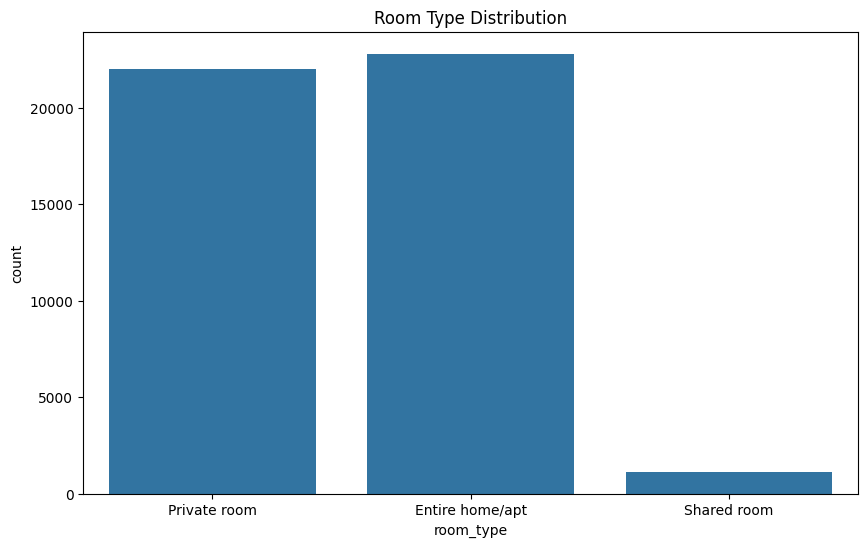

In [31]:
# Chart - 3 Room type Distribution
plt.figure(figsize = (10, 6))

sns.countplot(x = 'room_type', data = df_copy)

plt.title('Room Type Distribution')
plt.show()


##### 1. Why did you pick the specific chart?

 A count plot was chosen to analyze the frequency distribution of different room types listed in Airbnb.



##### 2. What is/are the insight(s) found from the chart?

Private Room and Entire Home or Apartment Room are the most dominant types in Airbnb and shared room type represent only a proportion of the listings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The NYC Airbnb market is driven by the private and Entire home type properties, indicating strong demand for privacy and independent stays.

Business Impact   
-> Higher booking potential   
-> Increased host participation   
-> Strong market expansion opportunities for premium and mid-range stays


#### Chart - 4  **Neighbourhood group distribution**

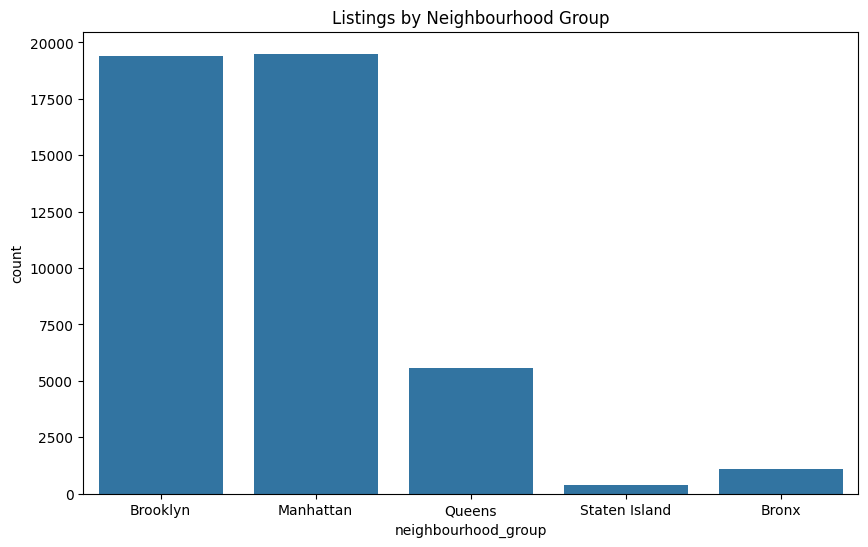

In [32]:
# Chart - 4 Neighbourhood group distribution
plt.figure(figsize = (10, 6))

sns.countplot(x = 'neighbourhood_group', data = df_copy)

plt.title('Listings by Neighbourhood Group')
plt.show()

##### 1. Why did you pick the specific chart?

Count plot was used to show the distribution of listings based on different neighbourhood group.

##### 2. What is/are the insight(s) found from the chart?

The distribution indicates the highest listings in Brooklyn and Manhattan region.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Over-concentration of listings in Manhattan and Brooklyn increases competetion among hosts while limiting platform expansion in other regions.

Business Impact

-> Saturated markets in premium areas  
-> Reduced host profitability due to competition   
-> Missed growth opportunities in underrepresented regions

#### Chart - 5  **Avaialbility distribution**

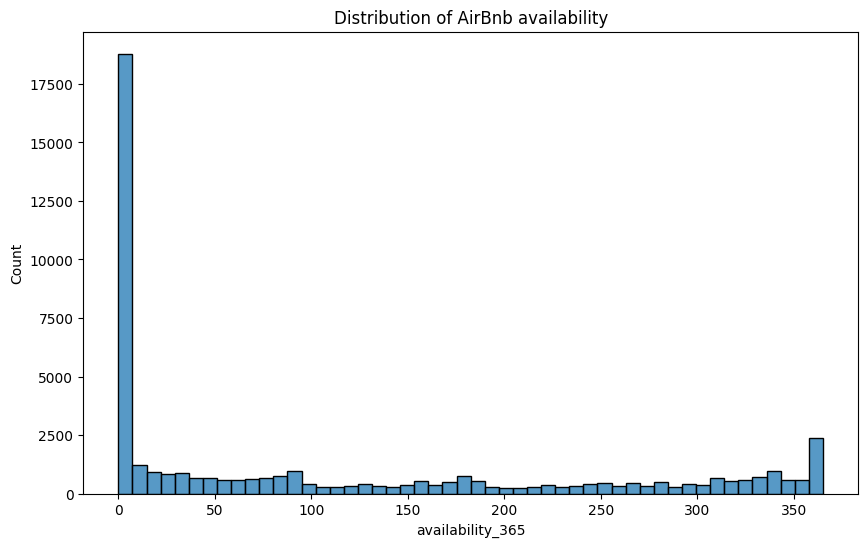

In [33]:
# Chart - 5 Avaialbility distribution
plt.figure(figsize = (10, 6))

sns.histplot(df_copy['availability_365'], bins = 50)

plt.title('Distribution of AirBnb availability')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram of availablity of the listed properties was used to see how it varies across listings.

This is an important parameter with respect to the occupancy rate and the demand for the listings.

##### 2. What is/are the insight(s) found from the chart?

 A good number of listings are almost not available showing a high demand for those listings. Also, there are a significant number of listings indicating year-round availability, which shows they are not very popular enough for customers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Lower availability of listings implies higher demand.
Business impact:  
-> High occupancy rate  
-> Stable long-term revenue generation    
-> Improved customer retention


**

High availability for some listings can indicate that properties are not being booked frequently.

Business Impact   
->Poor occupancy performance    
->Reduced host revenue    
->Potential mismatch between pricing and market demand

#### Chart - 6 **Number of reviews Distribution**

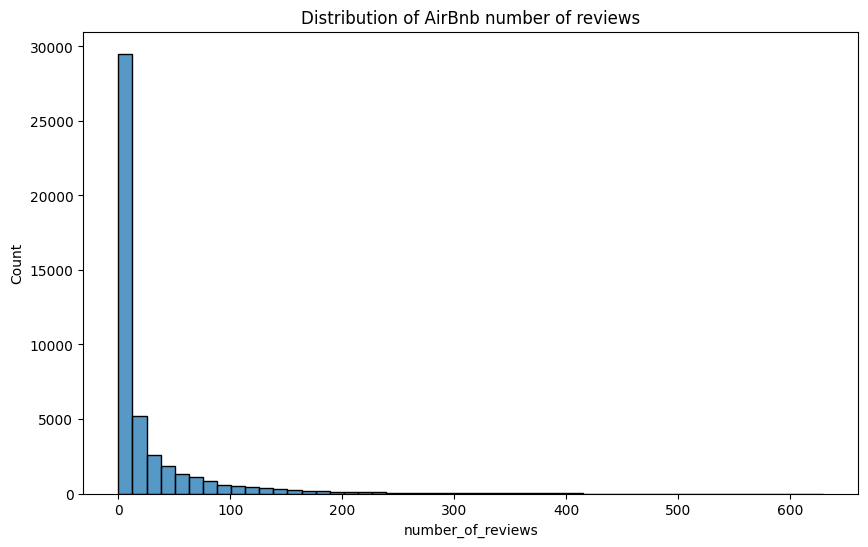

In [34]:
# Chart - 6 Number of reviews Distribution
plt.figure(figsize = (10, 6))

sns.histplot(df_copy['number_of_reviews'], bins = 50)

plt.title('Distribution of AirBnb number of reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was used to understand the distribution of number of reviews per listing.  

##### 2. What is/are the insight(s) found from the chart?

A very high number of listings have almost zero review. This might include new listings which have no reviews yet.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Listings with reviews means customer engagement. And good nummber of reviews build trust and credibility attracting more bookings.

The listings with no review would have a negative impact for the listings. This might decrease the occupancy rate.

Business Impact   
-> Reduced customer confidence    
-> Lower booking probability    
-> Lower host visibility and revenue generation

#### Chart - 7 **Minimum nights Distribution**

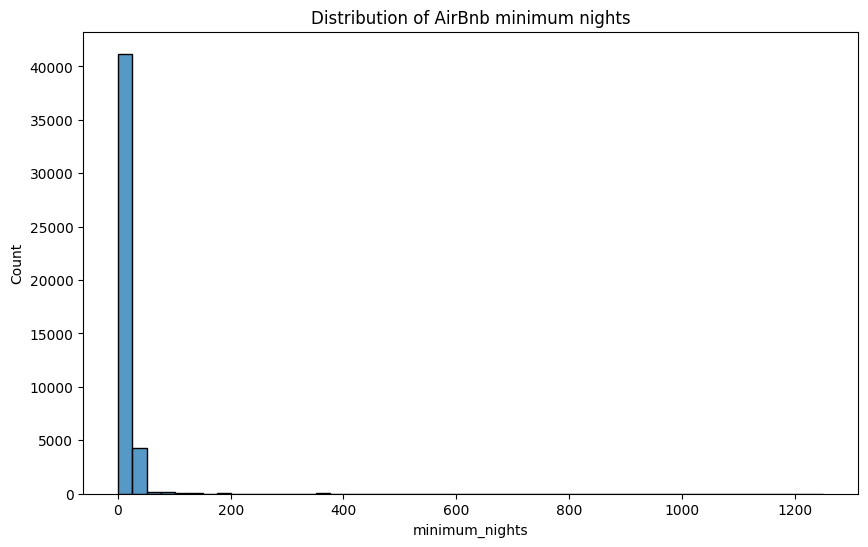

In [35]:
# Chart - 7 Minimum nights Distribution
plt.figure(figsize = (10, 6))

sns.histplot(df_copy['minimum_nights'], bins = 50)

plt.title('Distribution of AirBnb minimum nights')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was used to show the distribution of Minimum nights needed to book for the listings as part of their requirements.

##### 2. What is/are the insight(s) found from the chart?

Most of the listings have the requirement of booking for very low minimum night. However, some are listed on requirement of very high minimum nights.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Low minimum night requirement would attract more users as they provide flexibility for short-term stays.
Business Impact   
-> High turnover for short-term stays   
-> Increased booking frequency

Listings with high minimum stay requirement would lose demand as many users prefer a flexible short-term stay.

Business Impact  
-> lower booking frequency      
-> reduced demand for short-term visitors




-----------------
**Bivariate Analysis**
-----------------
-----------------


#### Chart - 8 **Price vs Room type**

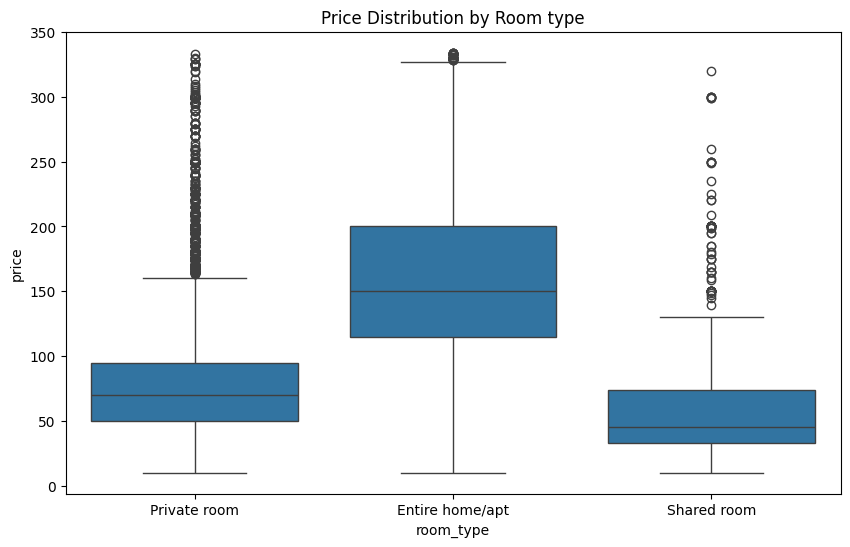

In [36]:
# Chart - 8 Price vs Room type
plt.figure(figsize = (10, 6))

sns.boxplot(x = 'room_type', y = 'price', data = df_copy)

plt.title('Price Distribution by Room type')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot was used to compare the pricing between different room types and identify median pricing, spread and outliers.

##### 2. What is/are the insight(s) found from the chart?

Entire home or apartments exhibit the highest median price and spread among all. And, shared room types have the lowest median price.

Room types certainly influence the pricing, with entire homes in the premium market segment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business impact

Airbnb hosts offering entire homes can generate more revenue.

Airbnb can promote the high-end premium stays to high-budget travellers.

**

Negative business impact

Higher pricing in premium segment might reduce occupancy if not aligned with market demand.

#### Chart - 9 **Price vs Neighbourhood Group**

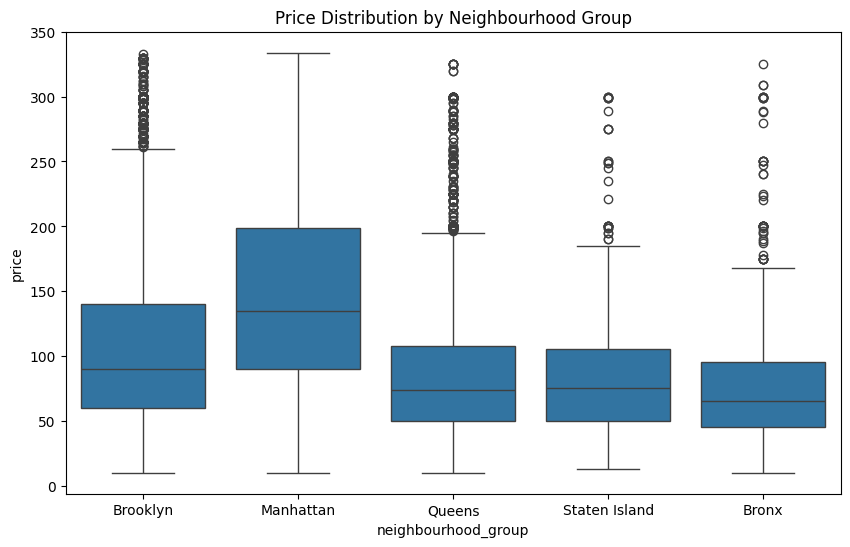

In [37]:
# Chart - 9 Price vs Neighbourhood group
plt.figure(figsize = (10,6))

sns.boxplot(x = 'neighbourhood_group', y = 'price', data = df_copy)

plt.title('Price Distribution by Neighbourhood Group')

plt.show()


##### 1. Why did you pick the specific chart?

A boxplot was used to understand the price distribution in relation to different neighbourhood group.



##### 2. What is/are the insight(s) found from the chart?

Manhattan shows the highest median price and variation followed by Brooklyn. Queens and Staten island have similar price distribution while Bronx has slightly less median value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Location surely drives the price distribution in Airbnb listings.

Positive Business impact

A higher variability in price ranges in Manhattan listings suggests availabity of wide variety of options. This might increase revenue by promoting strategically to diffrent customer segments.

**

Negative Business impact

The higher price segment in Manhattan and Brooklyn might decrease the occupancy rate.

#### Chart - 10 **Availability vs Room type**

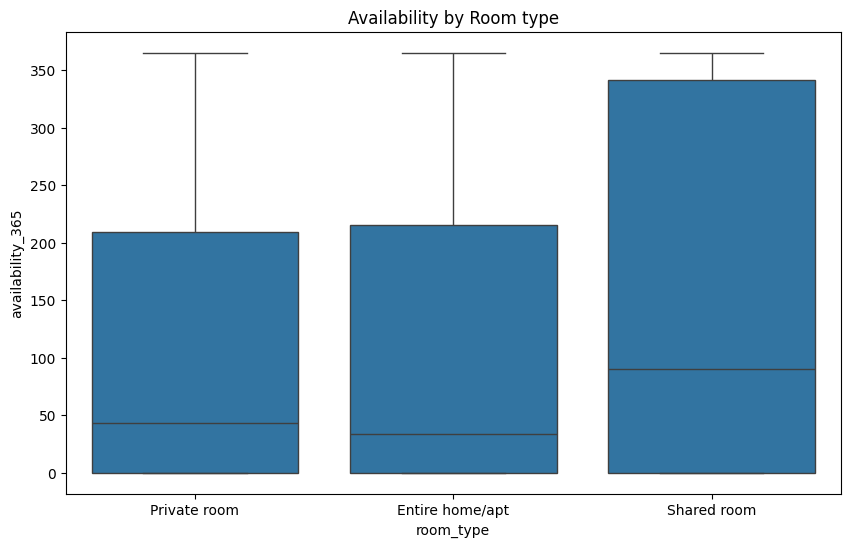

In [38]:
# Chart - 10 Availabilty vs Room type
plt.figure(figsize=(10,6))

sns.boxplot(x = 'room_type', y = 'availability_365', data = df_copy)

plt.title('Availability by Room type')

plt.show()

##### 1. Why did you pick the specific chart?

A boxplot has been used to analyze the availabilty based on different room types. Availability is linked with occupancy and demand. So, it will help us understand the demand for different room types.

##### 2. What is/are the insight(s) found from the chart?

Entire home types have the lowest median availabilty and shared room types have the highest availabilty.

This cleary shows a higher occupancy and demand for the entire home and private rooms.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact

The higher demand for private room and entire home suggests customers prefer privacy and flexible accomodation over traditional hotels.

A balance between pricing and demand has the potential to increase the revenue for entire home and private rooms.

Negative business impact

High availabilty of shared rooms suggest a low demand for shared room type.


#### Chart - 11 **Price vs No. of reviews**

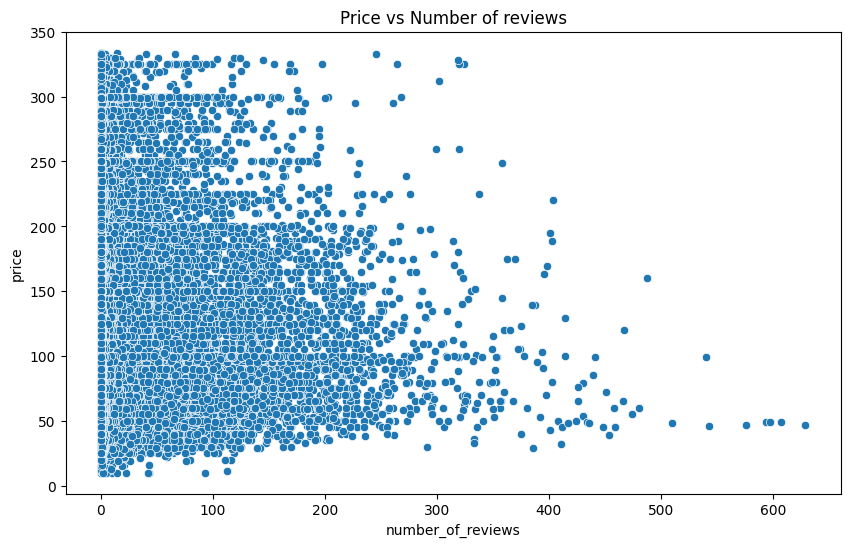

In [39]:
# Chart - 11 Price vs Number of reviews
plt.figure(figsize = (10, 6))

sns.scatterplot(x = 'number_of_reviews', y = 'price', data = df_copy)

plt.title('Price vs Number of reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A scatterplot was used to understand how number of reviews is related with different price segment.

##### 2. What is/are the insight(s) found from the chart?

Moderately priced listings have more number of reviews indicating more customer engagement and demand for moderate price segment.

And higher price stays have less number of reviews.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The moderately priced accomodation have higher reviews. This will create a positive impact for the business promoting more bookings in moderate budget segment.

Positive Business impact

-> More occupancy and demand for stays in moderate price range

Negative business impact

-> Higher or premium segment with less reviews indicate low customer engagement.
-> This would decrease occupancy rate for premium stays




#### Chart - 12  **Room type across neighbourhoods**

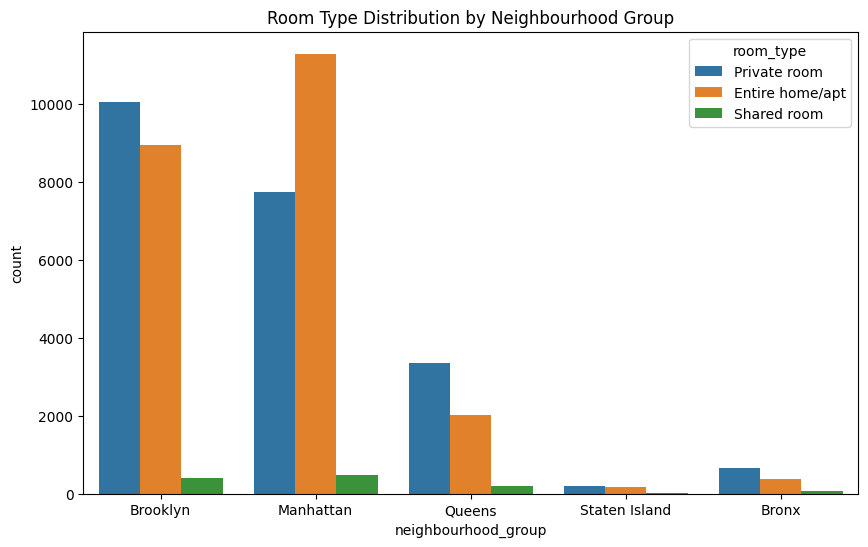

In [40]:
# Chart - 12 Room type across neighbourhoods
plt.figure(figsize = (10, 6))

sns.countplot(x = 'neighbourhood_group', hue = 'room_type', data = df_copy)

plt.title('Room Type Distribution by Neighbourhood Group')
plt.show()


##### 1. Why did you pick the specific chart?

Room type and neighbourhood are important drivers of the Airbnb pricing as observed in the univariate analysis.

Now, it would be good to see how the room types are distributed in different neighbourhoods. So, a countplot was used for neighbourhoods with room type as the hue parameter.

##### 2. What is/are the insight(s) found from the chart?

It has been already observed that the entire home and private room listings dominate in comparison to the shared room types. This observation is also evident in the room type ditribution across neighbourhoods.

Specifically, Manhattan contains a larger proportion of entire homes while other regions show stronger private room representation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Based on the distribution act=ross neighbourhoods, Airbnb can target different customer segments for different regions, e.g. luxury travellers in Manhattan, Brooklyn and budget travellers in Bronx, Queens.

Positive Business impact

-> Higher revenue generation for entire homes in Manhattan and Brooklyn

Negative Business impact

-> Increased competition among hosts in Manhattan and Brooklyn due to high no. of listings

-> Low representation in Bronx, Staten and Queen implies limited expansion, missing opportunity for diversification in these areas


#### Chart - 13 - Correlation Heatmap

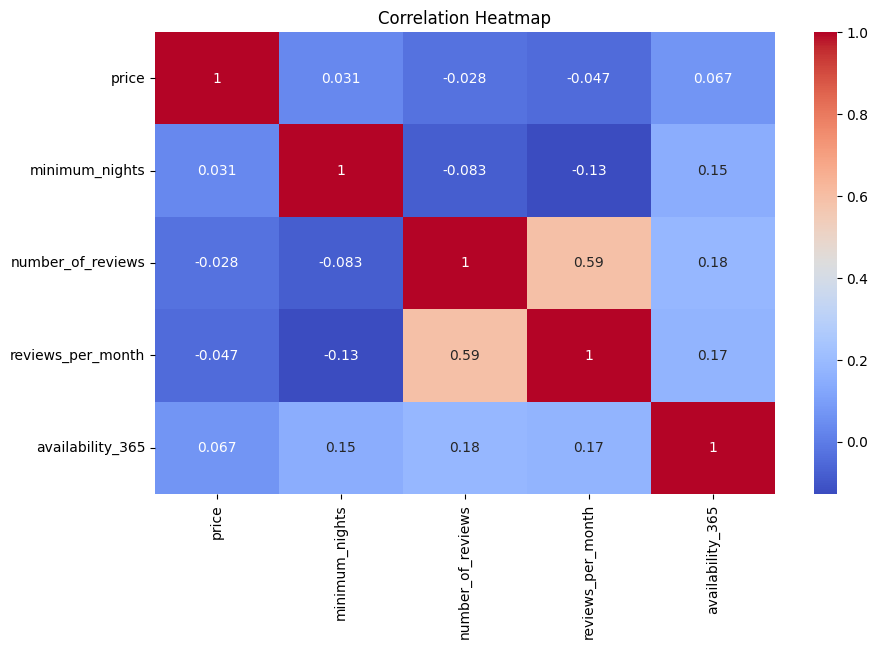

In [41]:
# Correlation Heatmap visualization code
plt.figure(figsize = (10, 6))

sns.heatmap(df_copy[['price',
                     'minimum_nights',
                     'number_of_reviews',
                     'reviews_per_month',
                     'availability_365']].corr(), annot = True,
            cmap = 'coolwarm')

plt.title('Correlation Heatmap')

plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was use to examine the strength and direction of relationships between numerical variables in the dataset. This visualization helps identify patterns, dependencies and factors infuencing price, occupancy and demand.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows overall weak to moderate correlations among variables indicating that the Airbnb listing performance is influenced by multiple factors rathar a single dominant variable.

A negative correlation has been observed between availability_365 and review related variables number_of_reviews and reviews_per_month, suggesting that the the listings with higher review activity are less available.

number_of_reviews and reviews_per_month has a positive correlation suggesting the listings with higher total reviews continue to maintain customer engagement over time.

However, pricing has no strong correlation with any variable, implying it is affected by other additional factors such as neighbourhood, room_type etc.

#### Chart - 15 - Pair Plot

In [42]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***